# Modelo de clasificación en Riesgo de Crédito

## El Problema de Negocio:
Imagina que trabajas en el departamento de Riesgos de un banco. Cada día llegan miles de solicitudes de tarjetas de crédito. Aprobar a un cliente que luego no paga (moroso) le cuesta mucho dinero al banco. Rechazar a un buen cliente significa perder ingresos y dárselos a la competencia. 

## Objetivo:
Construir un modelo de Machine Learning capaz de clasificar si un cliente es de "Alto Riesgo" (```Label``` = 1) o "Bajo Riesgo" (``Label`` = 0) basándonos en sus datos demográficos y financieros antes de concederle la tarjeta. 

## Marco de Coste de Negocio

Vamos a asignar un coste aproximado (ilustrativo, no oficial del banco) a cada tipo de error, para poder traducir cualquier métrica a dólares en cualquier punto del análisis:

- **Falso Negativo (FN):** aprobamos una tarjeta a alguien que termina siendo moroso. Coste: el capital que el banco pierde de golpe. Lo fijamos en **8.000$** de media por caso.

- **Falso Positivo (FP):** rechazamos a un cliente que en realidad era bueno pagador. Coste: el margen de intereses que dejamos de ganar y que probablemente se lleva la competencia. Lo fijamos en **400$** de media por caso.

La proporción (20:1) no es casualidad. En riesgo de crédito, un impago suele doler bastante más que un rechazo de más. Este marco es exactamente lo que vamos a usar más adelante para elegir el umbral de decisión y para la traducción final a euros de cada modelo.

## El Contexto de Negocio

Imagina que trabajas en el departamento de Admisión de Riesgos de un banco. Cada día, miles de clientes solicitan una nueva tarjeta de crédito a través de la app. El problema es crítico: cada vez que el banco le da una tarjeta a un cliente que luego no paga (moroso), se pierden miles de euros de golpe. Pero si el banco se asusta y rechaza a los buenos clientes, le está regalando el negocio y los intereses a la competencia.

La dirección te ha entregado un histórico de clientes reales. Su objetivo es claro: necesitan un modelo de *Credit Scoring* automático que sea capaz de predecir si un solicitante es de Alto Riesgo o Bajo Riesgo en tiempo real, antes de concederle el dinero.

### Importamos librerias

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import  RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

# Tema visual oscuro
plt.style.use('default')

plt.rcParams.update({
    'figure.figsize': (5, 4),

    'axes.facecolor': '#FFFFFF',
    'figure.facecolor': '#FFFFFF',

    'axes.edgecolor': '#D0D7DE',

    'grid.color': '#E5E7EB',
    'grid.linestyle': '--',
    'grid.alpha': 0.8,

    'font.size': 10,
})

Definimos costes de cada decisión

In [124]:
COSTE_FALSO_NEGATIVO = 8000   # $ perdidos por aprobar a un moroso
COSTE_FALSO_POSITIVO = 400    # $ de oportunidad perdidos por rechazar a un buen cliente

print(f"Ratio de coste FN/FP: {COSTE_FALSO_NEGATIVO / COSTE_FALSO_POSITIVO:.0f}:1")

Ratio de coste FN/FP: 20:1


In [125]:
# carga de los CSV y hacemos merge por la columna en comun Ind_ID
df_features = pd.read_csv("../data/raw/Credit_card.csv")
df_labels = pd.read_csv("../data/raw/Credit_card_label.csv")

df = pd.merge(df_features, df_labels, on="Ind_ID", how="inner")

Antes de continuar, verificamos si hicimos bien el merge de las dos tablas con el fin de observar si no obviamos alguna filas, ademas de analizar si existen filas duplicadas. 

In [126]:
ids_solo_features = set(df_features["Ind_ID"]) - set(df_labels["Ind_ID"]) 
ids_solo_labels = set(df_features["Ind_ID"]) - set(df_labels["Ind_ID"])

# validación de duplicados
duplicados_features = df_features['Ind_ID'].duplicated().sum()
duplicados_labels = df_labels['Ind_ID'].duplicated().sum()

# Filas perdidas
filas_perdidas = len(df_features) - len(df)

print(f"Clientes con datos pero sin etiqueta de riesgo: {len(ids_solo_features)}")
print(f"Clientes con etiquetas pero sin datos: {len(ids_solo_labels)}")

print(f"IDs duplicados en features: {duplicados_features}")
print(f"IDs duplicados en labels: {duplicados_labels}")

print(f"\nFilas descartadas por el inner join: {filas_perdidas} ({100*filas_perdidas/len(df_features):.2f}% del total)")

Clientes con datos pero sin etiqueta de riesgo: 0
Clientes con etiquetas pero sin datos: 0
IDs duplicados en features: 0
IDs duplicados en labels: 0

Filas descartadas por el inner join: 0 (0.00% del total)


Ahora renombramos las variables para mayor comodidad y consistencia a la hora de hacer el anlaisis exploratorio. 

In [127]:
df = df.rename(columns={
    'Ind_ID'        :   'id',
    'GENDER'        :   'gender',
    'Car_Owner'     :   'car_owner',
    'Propert_Owner' :   'propert_owner',
    'CHILDREN'      :   'children',
    'Annual_income' :   'annual_income',
    'Type_Income'   :   'type_income',
    'EDUCATION'     :   'education',
    'Marital_status':   'marital_status',
    'Housing_type'  :   'housing_type',
    'Birthday_count':   'birthday_count',
    'Employed_days' :   'employed_days',
    'Mobile_phone'  :   'mobile_phone',
    'Work_Phone'    :   'work_phone',
    'Phone'         :   'phone',
    'EMAIL_ID'      :   'email_id',
    'Type_Occupation':  'type_occupation',
    'Family_Members':   'family_members'

})
df.head()

,id,gender,car_owner,propert_owner,children,annual_income,type_income,education,marital_status,housing_type,birthday_count,employed_days,mobile_phone,work_phone,phone,email_id,type_occupation,family_members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


## Exploraremos las variables

Analizaremos algunas correlaciones de las variables para tomar mejores decisiones de imputación. 

Observamos que la distribución de pagadores no esta equilibrada, por un lado vemos que la basta mayoria 88% son buenos pagadores;sin embargo, tenemos una minoria del 11% que no son buenos pagadores. 

label
0    0.886951
1    0.113049
Name: proportion, dtype: float64


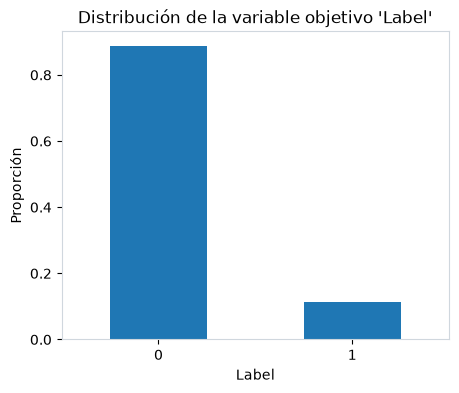

In [128]:
print(df["label"].value_counts(normalize=True))

df["label"].value_counts(normalize=True).plot(kind="bar")

plt.title("Distribución de la variable objetivo 'Label'")
plt.xlabel("Label")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

En el análisis descriptivo observamos variables de propiedad `car_owner`, `propert_owner` `email_id`,`work_phone`,`phone`,`mobile_phone` veremos si tiene relación con ser un buen pagador o no. 

In [129]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1548.0,5.078920e+06,41717.587742,5008827.0,5045069.75,5078841.5,5115673.00,5150412.0
children,1548.0,4.127907e-01,0.776691,0.0,0.00,0.0,1.00,14.0
annual_income,1525.0,1.913993e+05,113252.997656,33750.0,121500.00,166500.0,225000.00,1575000.0
birthday_count,1526.0,-1.604034e+04,4229.503202,-24946.0,-19553.00,-15661.5,-12417.00,-7705.0
employed_days,1548.0,5.936469e+04,137808.062701,-14887.0,-3174.50,-1565.0,-431.75,365243.0
mobile_phone,1548.0,1.000000e+00,0.000000,1.0,1.00,1.0,1.00,1.0
work_phone,1548.0,2.080103e-01,0.406015,0.0,0.00,0.0,0.00,1.0
phone,1548.0,3.094315e-01,0.462409,0.0,0.00,0.0,1.00,1.0
email_id,1548.0,9.237726e-02,0.289651,0.0,0.00,0.0,0.00,1.0
family_members,1548.0,2.161499e+00,0.947772,1.0,2.00,2.0,3.00,15.0


Verificamos el formato de nuestras variables, parece todo estar correcto. Y eliminamos `id` ya que solo este es un identificador. 

In [130]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1548 non-null   int64  
 1   gender           1541 non-null   str    
 2   car_owner        1548 non-null   str    
 3   propert_owner    1548 non-null   str    
 4   children         1548 non-null   int64  
 5   annual_income    1525 non-null   float64
 6   type_income      1548 non-null   str    
 7   education        1548 non-null   str    
 8   marital_status   1548 non-null   str    
 9   housing_type     1548 non-null   str    
 10  birthday_count   1526 non-null   float64
 11  employed_days    1548 non-null   int64  
 12  mobile_phone     1548 non-null   int64  
 13  work_phone       1548 non-null   int64  
 14  phone            1548 non-null   int64  
 15  email_id         1548 non-null   int64  
 16  type_occupation  1060 non-null   str    
 17  family_members   1548 non

In [131]:
df.drop("id", axis=1, inplace=True)

verificaremos los nulos. Vemos que tenemos una variable con muchos nulos `type_occupation` - En este punto nace una pregunta imporante: ¿El cliente esta desempleado, por eso la la casilla es nula? 

In [132]:
df.isnull().sum()

gender               7
car_owner            0
propert_owner        0
children             0
annual_income       23
type_income          0
education            0
marital_status       0
housing_type         0
birthday_count      22
employed_days        0
mobile_phone         0
work_phone           0
phone                0
email_id             0
type_occupation    488
family_members       0
label                0
dtype: int64

Demos un vistazo general de los valores únicos de las variables categóricas. Vemos que variables como `type_occupation` , `housing_type` & `education` podemos agrupar algunos de sus elementos sin agregar mucho ruido. 

In [133]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for cat in cat_cols:
    print("-----")
    print(df[cat].value_counts(dropna=False))
    print()

-----
gender
F      973
M      568
NaN      7
Name: count, dtype: int64

-----
car_owner
N    924
Y    624
Name: count, dtype: int64

-----
propert_owner
Y    1010
N     538
Name: count, dtype: int64

-----
type_income
Working                 798
Commercial associate    365
Pensioner               269
State servant           116
Name: count, dtype: int64

-----
education
Secondary / secondary special    1031
Higher education                  426
Incomplete higher                  68
Lower secondary                    21
Academic degree                     2
Name: count, dtype: int64

-----
marital_status
Married                 1049
Single / not married     227
Civil marriage           101
Separated                 96
Widow                     75
Name: count, dtype: int64

-----
housing_type
House / apartment      1380
With parents             80
Municipal apartment      53
Rented apartment         21
Office apartment          9
Co-op apartment           5
Name: count, dtype: int64

--

## Análisis exploratorio de variables (EDA)

Definimos nuestras variables categóricas y numéricas para facilitar el análisi, observamos que las variables binarias son consideradas como categóricas. Convertiremos sus valores para que sean consideradas binarias en `Y/N` a `1/0`

In [134]:
# Definimos variables categoricas y numericas
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variables categóricas: {cat_cols}")
print(f"Variables numéricas: {num_cols}")

Variables categóricas: ['gender', 'car_owner', 'propert_owner', 'type_income', 'education', 'marital_status', 'housing_type', 'type_occupation']
Variables numéricas: ['children', 'annual_income', 'birthday_count', 'employed_days', 'mobile_phone', 'work_phone', 'phone', 'email_id', 'family_members', 'label']


In [135]:
cols = ['car_owner', 'propert_owner']
df[cols] = df[cols].replace({'Y': 1 , 'N': 0})

CAT_COLS = ['gender', 'type_income', 'education', 'marital_status', 'housing_type', 'type_occupation']
NUM_COLS = ['children', 'annual_income', 'birthday_count', 'employed_days', 'family_members']
BIN_COLS = ['car_owner', 'propert_owner','mobile_phone', 'work_phone','phone', 'email_id']

print(f"Variables categóricas: {CAT_COLS}")
print(f"Variables numéricas: {NUM_COLS}")
print(f"Variables binarias: {BIN_COLS}")

Variables categóricas: ['gender', 'type_income', 'education', 'marital_status', 'housing_type', 'type_occupation']
Variables numéricas: ['children', 'annual_income', 'birthday_count', 'employed_days', 'family_members']
Variables binarias: ['car_owner', 'propert_owner', 'mobile_phone', 'work_phone', 'phone', 'email_id']


Ahora analizamos los valores únicos de estas variables, para ver si existe algún error de tipeo. Bien Observamos que `mobile_phone` solo cuenta con elemento, podemos eliminarlo ya que no afectara a nuestro modelo. 

In [136]:
for c in BIN_COLS:
    print(c, df[c].unique())

car_owner [1 0]
propert_owner [1 0]
mobile_phone [1]
work_phone [0 1]
phone [0 1]
email_id [0 1]


In [137]:
# Eliminamos la variable mobile_phone
df.drop('mobile_phone', axis=1, inplace=True)

Ahora analicemos la estadística descriptiva de las variables numéricas. Aquí me nace una duda, si la variable `children` y `familia_members` estan correlacionadas. 

In [138]:
df[NUM_COLS].describe()

,children,annual_income,birthday_count,employed_days,family_members
count,1548.000000,1.525000e+03,1526.000000,1548.000000,1548.000000
mean,0.412791,1.913993e+05,-16040.342071,59364.689922,2.161499
std,0.776691,1.132530e+05,4229.503202,137808.062701,0.947772
min,0.000000,3.375000e+04,-24946.000000,-14887.000000,1.000000
25%,0.000000,1.215000e+05,-19553.000000,-3174.500000,2.000000
50%,0.000000,1.665000e+05,-15661.500000,-1565.000000,2.000000
75%,1.000000,2.250000e+05,-12417.000000,-431.750000,3.000000
max,14.000000,1.575000e+06,-7705.000000,365243.000000,15.000000


In [139]:
print(df['children'].value_counts().sort_index())
print(df['family_members'].value_counts().sort_index())

children
0     1091
1      305
2      134
3       16
4        1
14       1
Name: count, dtype: int64
family_members
1     334
2     802
3     268
4     127
5      15
6       1
15      1
Name: count, dtype: int64


In [140]:
df.groupby(['family_members', 'children'])['children'].agg(['count']).reset_index()

,family_members,children,count
0,1,0,332
1,1,1,2
2,2,0,759
3,2,1,43
4,3,1,260
5,3,2,8
6,4,2,126
7,4,3,1
8,5,3,15
9,6,4,1


Efectivamente, las variables `family_members` y `childnre` estan correlacionadas de algún modo. Esto lo trataremos mas adelante con el VIF, y decidiremos si eliminarlo o no. Además vemos que muchas familias sin hijos o son unico miembro de una familia. 

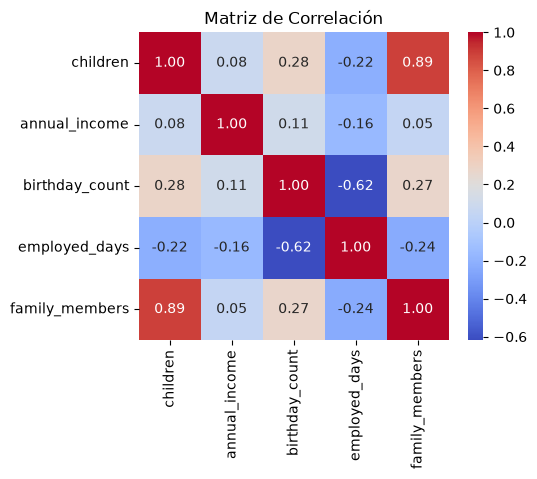

In [141]:
correlation_matrix = df[NUM_COLS].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

Vemos que existe más cantidad de mujeres que optan por tener una tarjeta de crédito. Y además que la mayoria no es dueño de un vehículo; sin embargo, la mayoria es dueño de una propiedad, que probablemente sirva para garantizar que un usuario sea buen pagador. 

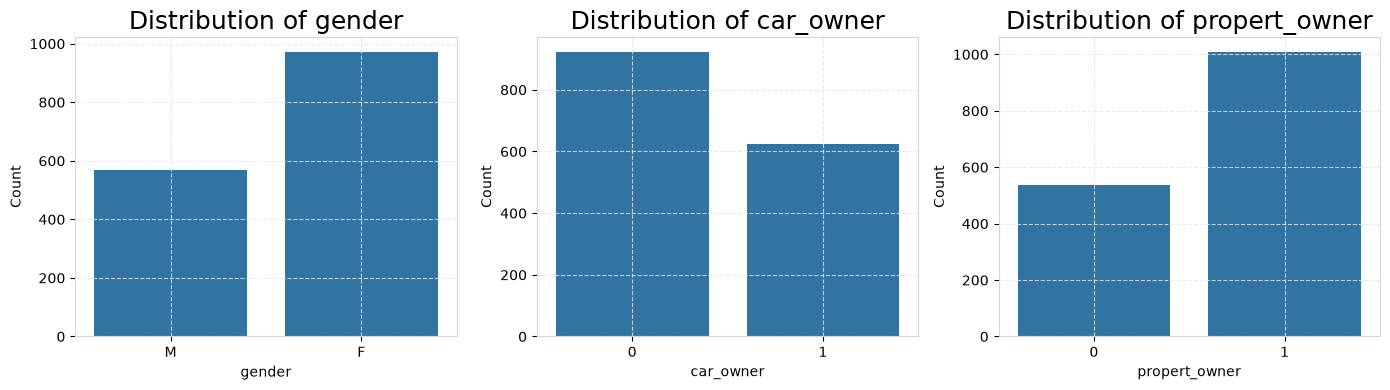

In [142]:
cols = ['gender', 'car_owner', 'propert_owner']

# Set up the figure and axes

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 4))

# Plot univariate distributions for each column
for i, col in enumerate(cols):
    sns.countplot(data=df , x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}' , fontsize=18 )
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Pues parece que no existe ningún patron interesante para inputar la variable `annual_income`, podemos imputarlo usando la mediana. Además, observamos que tiene algunos outliers una amplia cola a la derecha. 

In [143]:
df[df['annual_income'].isna()][['type_income' ]].value_counts()

type_income         
Working                 11
Commercial associate     8
Pensioner                4
Name: count, dtype: int64

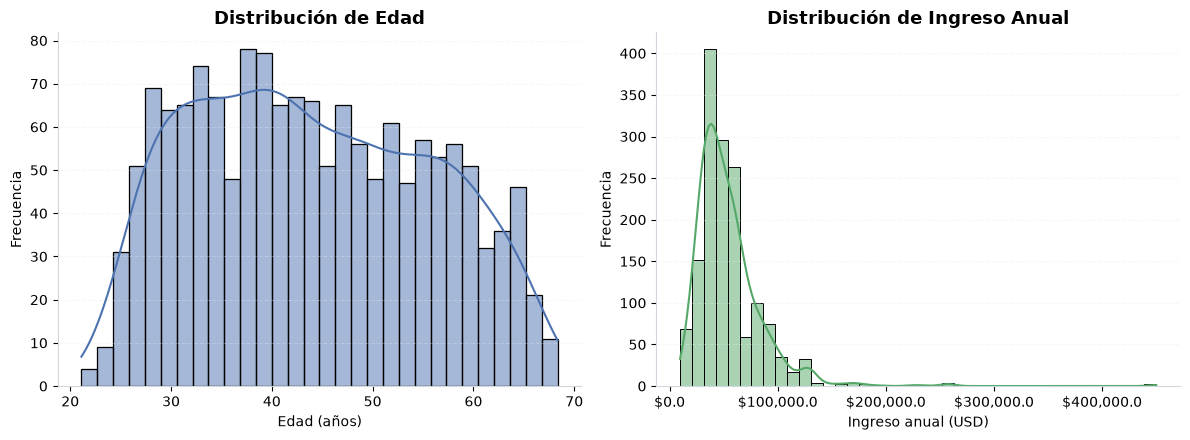

In [144]:
from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Distribucion de edad
age_tmp = -df['birthday_count'] / 365

sns.histplot(age_tmp.dropna(),bins=30,kde=True,ax=axes[0],color = '#4C72B0')

axes[0].set_title('Distribución de Edad',fontsize=13,fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')

# Distribucion ingreso anual
exchange_rate = 3.50

income_usd = df['annual_income'] / exchange_rate

sns.histplot(income_usd.dropna(),bins=40,kde=True,ax=axes[1],color='#55A868')

axes[1].set_title('Distribución de Ingreso Anual',fontsize=13,fontweight='bold')
axes[1].set_xlabel('Ingreso anual (USD)')
axes[1].set_ylabel('Frecuencia')

# Formato del eje X del ingreso
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.1f}'))

for ax in axes:
    ax.grid(axis='y',linestyle='--',alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Seguimos con `birthday_count` y vemos que no existe algun tipo de patron interesante, porque cual imputaremos por la mediana. 

In [145]:
df[df['birthday_count'].isna()][['employed_days']].value_counts().reset_index()

,employed_days,count
0,365243,4
1,-586,1
2,-508,1
3,-583,1
4,-1190,1
5,-6908,1
6,-2052,1
7,-2276,1
8,-6693,1
9,-2959,1


Ahora agrupemos el tipo de ocupacion por el tipo de ingreso `type_occupation` & `type_income` en especial los valores nulos para tener alguna idea de que se podria imputar. Evidentemente, tenemos que `pensioner` con mas cantidad de valores faltantes, eso tendría sentido agruparlos como desconocidos, ya que un pensionistas se puede dedicar a diferentes actividades.

In [146]:
df[df['type_occupation'].isna()]['type_income'].value_counts()

type_income
Pensioner               264
Working                 129
Commercial associate     77
State servant            18
Name: count, dtype: int64

In [147]:
df.groupby(['type_income', 'education'])['label'].mean().sort_values(ascending=False).reset_index()

,type_income,education,label
0,Commercial associate,Lower secondary,0.500000
1,Working,Lower secondary,0.333333
2,Pensioner,Higher education,0.212766
3,Commercial associate,Higher education,0.194444
4,Pensioner,Secondary / secondary special,0.146226
5,Pensioner,Lower secondary,0.142857
6,Working,Incomplete higher,0.117647
7,Commercial associate,Secondary / secondary special,0.102564
8,Working,Secondary / secondary special,0.100358
9,State servant,Higher education,0.093023


Vemos que los pensionistas & los que son baja secundaria son los que tienen mayor tasa de morosidad. 

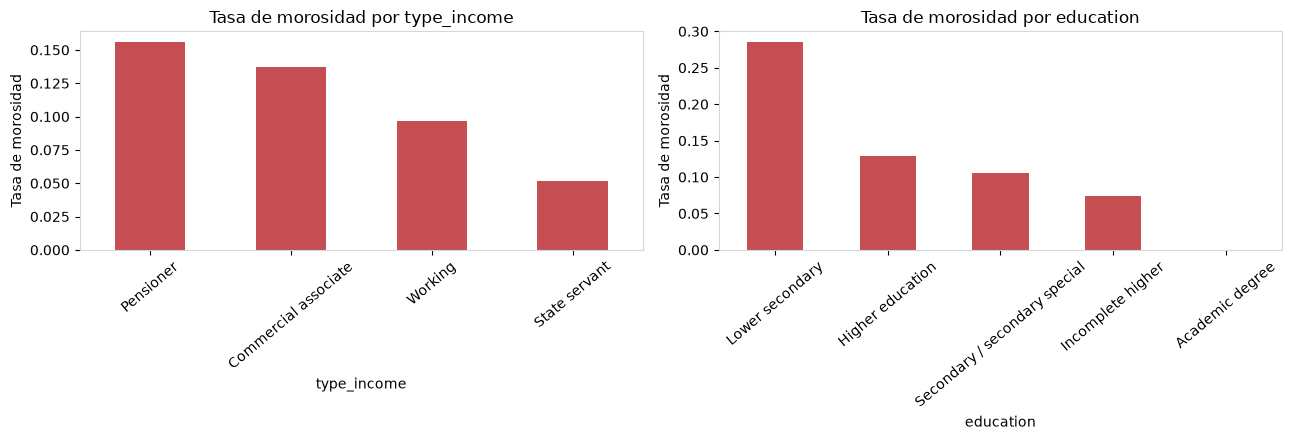

In [148]:
# Tasa de morosidad por variable categorica
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
for ax, col in zip(axes, ['type_income', 'education']):
    rate = df.groupby(col)['label'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_ylabel('Tasa de morosidad')
    ax.set_title(f'Tasa de morosidad por {col}')
    ax.tick_params(axis='x', rotation=40)
plt.tight_layout(); plt.show()

Siguiendo la dinánima del análisis, vemos que la variable `employed_days` tiene un valor de `365243.000000`. Exploraremos un poco más de que trata, y luego veremos si la variable tiene alguna relación con el `type_income`

In [149]:
df['employed_days'].describe()

count      1548.000000
mean      59364.689922
std      137808.062701
min      -14887.000000
25%       -3174.500000
50%       -1565.000000
75%        -431.750000
max      365243.000000
Name: employed_days, dtype: float64

Según el diccionario, vemos que la variable `employed_dias` enumera con negativo los dias que un usuario tiene en el mundo laboral. Por otra parte, vemos que no existe valores distintos de `365243`, lo que nos da entender como un codigo único de clasificación.

In [150]:
print(df['employed_days'].value_counts())


employed_days
 365243    261
-586         6
-3420        5
-622         5
-460         5
          ... 
-1648        1
-3536        1
-2182        1
-1209        1
-2859        1
Name: count, Length: 956, dtype: int64


In [151]:
df.loc[df['employed_days'] > 0, 'employed_days' ].value_counts()

employed_days
365243    261
Name: count, dtype: int64

Ahora veremos si ese codigo `365243` tiene alguna tipo de relación con el `type_income`. Como habiamos visto anteriormente, que podemos imputar algunos valores faltantes con la etiqueta de retirado o desempleado, ya que son pensionistas.

In [152]:
df[df['employed_days'] == 365243]['type_income'].value_counts()

type_income
Pensioner    261
Name: count, dtype: int64

## Limpieza básica

La variable `employed_days` tiene un codigo especial para identificar a los retirados, crearemos una nueva variable para identificar a los retirados y desempleados con 1 y los trabajadores con 0. Ademas, imputaremos ese codigo especial con 0, ya que nos da a entender que si un usuario no trabaja, por ahora colocaremos nan y después lo imputaremos

In [153]:
df['is_retired_unemployed'] =(df['employed_days'] == 365243).astype(int)

df.loc[df['employed_days'] == 365243, 'employed_days'] = np.nan

df.employed_days.isnull().sum()

np.int64(261)

Ahora agruparemos las categorias del modo que tenga sentido sin alterar ni agregar ruido. 

In [154]:
# Creamos el diccionario de mapeo con nuestra lógica de negocio
mapeo_profesiones = {
    # White Collar (Oficina / Alta cualificación)
    'IT staff': 'White_Collar',
    'Managers': 'White_Collar',
    'Core staff': 'White_Collar',
    'Accountants': 'White_Collar',
    'Medicine staff': 'White_Collar',
    'High skill tech staff': 'White_Collar',
    'HR staff': 'White_Collar',
    
    # Blue Collar (Manual / Operativo)
    'Laborers': 'Blue_Collar',
    'Drivers': 'Blue_Collar',
    'Security staff': 'Blue_Collar',
    'Low-skill Laborers': 'Blue_Collar',
    
    # Ventas y Administración
    'Sales staff': 'Sales_Services',
    'Realty agents': 'Sales_Services',
    'Secretaries': 'Sales_Services',
    
    # Hostelería y Limpieza
    'Cooking staff': 'Hospitality_Support',
    'Waiters/barmen staff': 'Hospitality_Support',
    'Cleaning staff': 'Hospitality_Support',
}

# Aplicamos el mapeo. Lo que no esté en el diccionario (los nulos), lo rellenamos con 'Desconocido'
df['type_occupation'] = df['type_occupation'].map(mapeo_profesiones).fillna('Unknown')
df['type_occupation'].value_counts()

type_occupation
Unknown                505
White_Collar           474
Blue_Collar            388
Sales_Services         133
Hospitality_Support     48
Name: count, dtype: int64

Bien, ahora hechemos un vistazo a las variables categoricas. Vemos que existe muchas categorias, por ejemplo podemos agrupar `education` y `housing_type`

In [155]:
CAT_COLS = ['gender', 'type_income', 'education', 'marital_status', 'housing_type', 'type_occupation']
NUM_COLS = ['children', 'annual_income', 'birthday_count', 'employed_days', 'family_members']
BIN_COLS = ['car_owner', 'propert_owner','work_phone','phone', 'email_id', 'is_retired_unemployed']


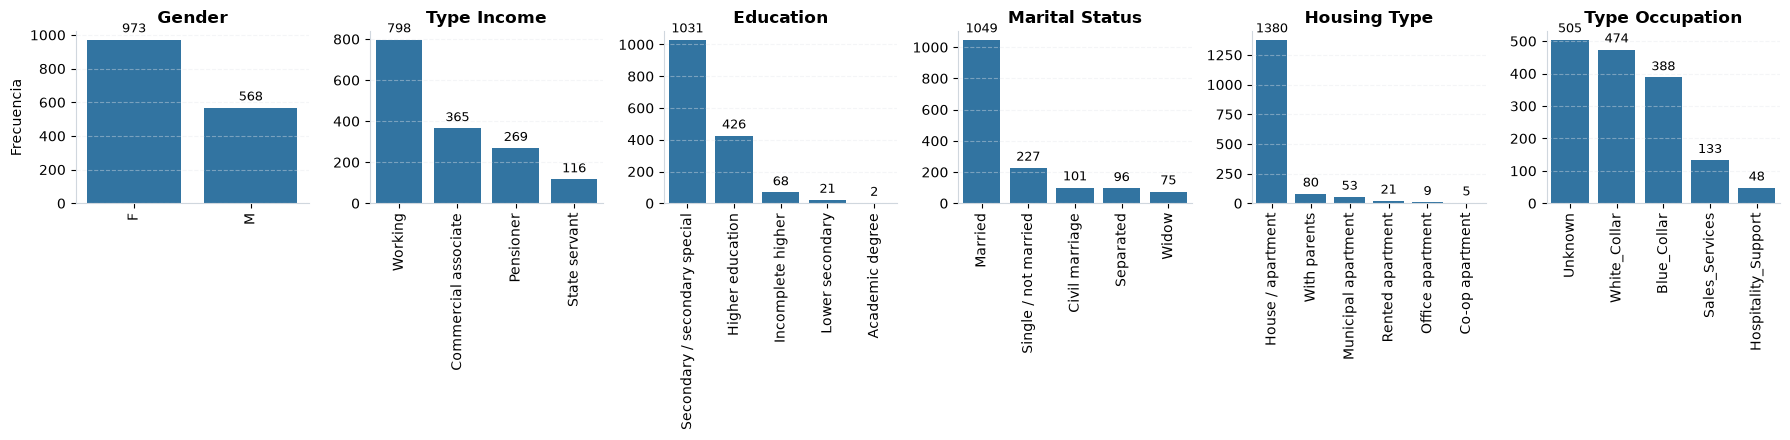

In [156]:
fig, axes = plt.subplots(
    ncols=6,
    nrows=1,
    figsize=(18, 4.5)
)

axes = axes.flatten()

for i, col in enumerate(CAT_COLS):

    sns.countplot(
        data=df,
        x=col,
        ax=axes[i],
        order=df[col].value_counts().index
    )

    axes[i].set_title(
        col.replace('_', ' ').title(),
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia' if i == 0 else '')

    # Rotar etiquetas
    axes[i].tick_params(
        axis='x',
        rotation=90
    )

    # Cuadrícula horizontal
    axes[i].grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    # Quitar bordes superiores y derechos
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    # Agregar valores encima de las barras
    for container in axes[i].containers:
        axes[i].bar_label(
            container,
            fmt='%d',
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()

Para `housing_type` agrupamos algunos elementos < a 60 como `Rent` 

In [157]:
# Definimos nuestro límite de obsercaciones
threshold = 60

# Calculamos cuántos clientes hay en cada categoría
frecuencia = df['housing_type'].value_counts()

# Filtramos y nos quedamos solo con los NOMBRES de las categorías que no llegan a X
categorias_raras = frecuencia[frecuencia < threshold].index

df['housing_type'] = df['housing_type'].replace(categorias_raras, 'Rent')

df['housing_type'].value_counts()


housing_type
House / apartment    1380
Rent                   88
With parents           80
Name: count, dtype: int64

Hacemos lo mismo con `educacion` 

In [158]:
df['education'] = df['education'].replace('Academic degree', 'Higher education')
df['education'] = df['education'].replace(['Lower secondary', 'Secondary / secondary special'], 'Secondary')
df.groupby('education')['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
education,,
Secondary,0.109316,1052
Higher education,0.128505,428
Incomplete higher,0.073529,68


In [159]:
df.isna().sum()

gender                     7
car_owner                  0
propert_owner              0
children                   0
annual_income             23
type_income                0
education                  0
marital_status             0
housing_type               0
birthday_count            22
employed_days            261
work_phone                 0
phone                      0
email_id                   0
type_occupation            0
family_members             0
label                      0
is_retired_unemployed      0
dtype: int64

# Ingeniería de variables

Renombraremos algunas variables para que tengan mas sentido comercial. Tal el caso de `birthday_count` por `age_years` & `employed_days` por `employment_years` y posteriormente eliminaremos las otras variables para no causar multicolinealidad.

In [160]:
# dividimos entre 365 dias que tiene un año
df['age_years'] = -df['birthday_count'] / 365

# Creamos una nueva columna y dividimos entre 365 sin seleccionar los nulos
df.loc[df['employed_days'].notna(), 'employment_years'] = -df.loc[df['employed_days'].notna(), 'employed_days'] / 365

# si un usuario es retirad o desempleado, agregamos 0 la columna employment_years
# por no tener experiencia laboral
df.loc[df['is_retired_unemployed'] == 1, 'employment_years'] = 0

In [161]:
df.isnull().sum()
df['employment_years'].value_counts()

employment_years
0.000000    261
1.605479      6
9.369863      5
1.704110      5
1.260274      5
           ... 
4.515068      1
9.687671      1
5.978082      1
3.312329      1
7.832877      1
Name: count, Length: 956, dtype: int64

In [162]:
#eliminamos las columnas antiguas para evitar la multicolinealidad
df = df.drop(columns=['birthday_count', 'employed_days'])

In [163]:
df.isnull().sum()

gender                    7
car_owner                 0
propert_owner             0
children                  0
annual_income            23
type_income               0
education                 0
marital_status            0
housing_type              0
work_phone                0
phone                     0
email_id                  0
type_occupation           0
family_members            0
label                     0
is_retired_unemployed     0
age_years                22
employment_years          0
dtype: int64

Ahora veremos los outliers, y diseñar un plan para hacer capping.

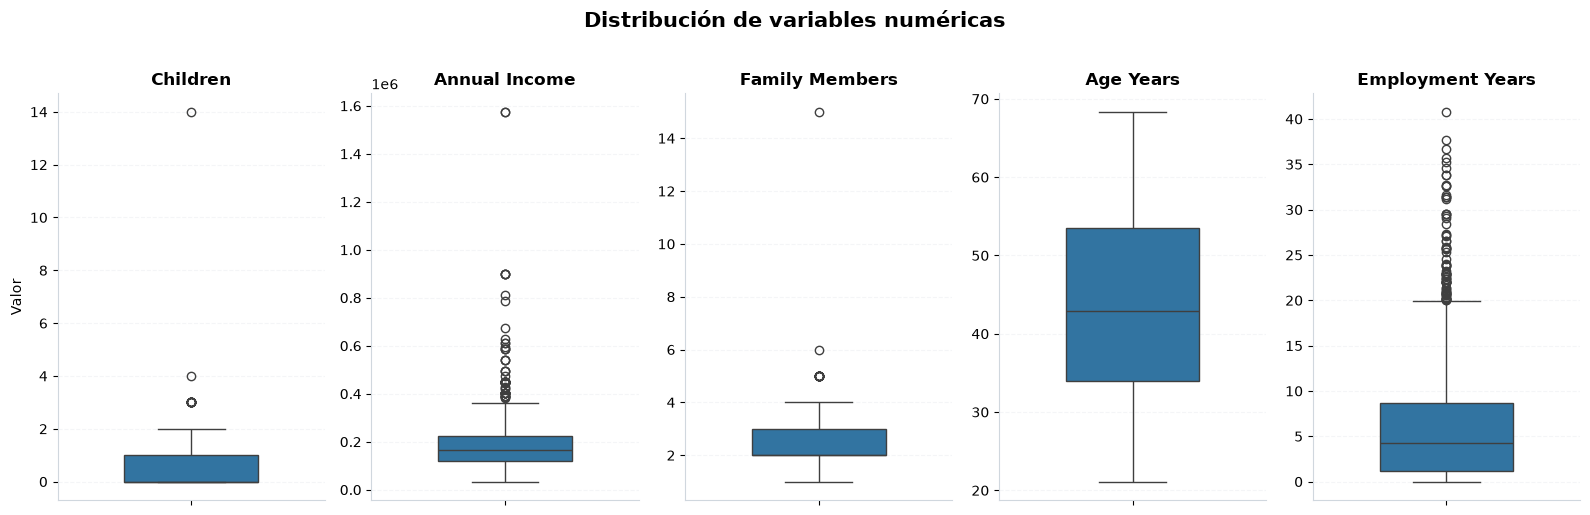

In [164]:

num_cols = [
    'children',
    'annual_income',
    'family_members',
    'age_years',
    'employment_years'
]

fig, axes = plt.subplots(
    ncols=len(num_cols),
    nrows=1,
    figsize=(16, 5)
)

for i, col in enumerate(num_cols):

    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        width=0.5
    )

    axes[i].set_title(
        col.replace('_', ' ').title(),
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor' if i == 0 else '')

    axes[i].grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle(
    'Distribución de variables numéricas',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

Vemos valores extremos en 3 variables, `children`, `family_members` y `employment_years`. Vamos a tratar los outliers con el limite IQR; sin embargo, para la ultima variable en un contexto real existe personas que trabajan por mas de 40 años. 

## Division entre Train y Split

Continuando, ahora separamos las variables predictoras de la indpendiente `label`, y usamos el metodo `stratify` para mantener la misma proporción después del split. 

In [165]:
X = df.drop(columns=['label'])
y = df['label']

# Usamos stratify para mantener la misma proporción tanto en train y test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: filas: {X_train.shape[0]} & columnas: {X_train.shape[1]}")
print(f"test: filas: {X_test.shape[0]} & columnas: {X_test.shape[1]}")
print()
print("Train balance:", y_train.value_counts(normalize=True))
print()
print("Test balance:", y_test.value_counts(normalize=True))

Train: filas: 1238 & columnas: 17
test: filas: 310 & columnas: 17

Train balance: label
0    0.886914
1    0.113086
Name: proportion, dtype: float64

Test balance: label
0    0.887097
1    0.112903
Name: proportion, dtype: float64


## Imputación de valores faltantes 

Continuamos con la imputación de valores faltantes. Importante: los valores de imputación se obtendran de train, despues se aplicará a test. 

1. `gender` se imputará usando la moda. 
2. `annual_income` se imputará usando la mediana por tipo de ingreso.
3. `age_years` se imputará por la mediana por tipo de ingreso. 

In [166]:
X_train.isnull().sum()

gender                    6
car_owner                 0
propert_owner             0
children                  0
annual_income            18
type_income               0
education                 0
marital_status            0
housing_type              0
work_phone                0
phone                     0
email_id                  0
type_occupation           0
family_members            0
is_retired_unemployed     0
age_years                21
employment_years          0
dtype: int64

In [167]:
#1. `gender` se imputará usando la moda. 
gender_mode = X_train['gender'].mode()[0]
print("Moda GENDER (train):", gender_mode)

#2. `annual_income` se imputará usando la mediana por tipo de ingreso.
income_medians = X_train.groupby('type_income')['annual_income'].median()
print("\nMedianas de ingreso por type_Income (train):\n", income_medians)

#3. `age_years` se imputará por la mediana por tipo de ingreso. 
age_medians = X_train.groupby('type_income')['age_years'].median()
print("\nMedianas de edad por type_Income (train):\n", age_medians)


Moda GENDER (train): F

Medianas de ingreso por type_Income (train):
 type_income
Commercial associate    180000.0
Pensioner               135000.0
State servant           180000.0
Working                 157500.0
Name: annual_income, dtype: float64

Medianas de edad por type_Income (train):
 type_income
Commercial associate    39.660274
Pensioner               60.279452
State servant           41.493151
Working                 39.650685
Name: age_years, dtype: float64


In [168]:
# Creamos una funcion para imputar tanto en train y test 

def apply_imputation(X, gender_mode, income_medians, age_medians):
    X = X.copy()
    X['gender'] = X['gender'].fillna(gender_mode)
    X['annual_income'] = X.apply(
        lambda r: income_medians.get(r['type_income'], income_medians.median()) if pd.isna(r['annual_income']) else r['annual_income'],
        axis=1
    )
    X['age_years'] = X.apply(
        lambda r: age_medians.get(r['type_income'], age_medians.median()) if pd.isna(r['age_years']) else r['age_years'],
        axis=1
    )
    return X

# Hacemos la imputacion en train y test
X_train = apply_imputation(X_train, gender_mode, income_medians, age_medians)
X_test = apply_imputation(X_test, gender_mode, income_medians, age_medians)

print("\nMissing tras imputacion (train):\n", X_train.isna().sum().sum())
print("Missing tras imputacion (test):\n", X_test.isna().sum().sum())


Missing tras imputacion (train):
 0
Missing tras imputacion (test):
 0


## Capping - Imputación de outliers 

A continuación imputaremos los outliers usando el rango intercuartílico (IQR) - winsorización a las siguientes 3 variables:`children`, `annual_income` & `family_members`

In [169]:
# Valores antes de la winsorización
num_cols_outliers = ['children', 'annual_income', 'family_members']
print(X_train[num_cols_outliers].describe())


         children  annual_income  family_members
count  1238.00000   1.238000e+03     1238.000000
mean      0.42811   1.894188e+05        2.168013
std       0.80575   1.147369e+05        0.980428
min       0.00000   3.780000e+04        1.000000
25%       0.00000   1.215000e+05        2.000000
50%       0.00000   1.575000e+05        2.000000
75%       1.00000   2.250000e+05        3.000000
max      14.00000   1.575000e+06       15.000000


In [170]:
# Calculamos IQR para las tres variables y guardamos en bound

bounds = {}
for c in num_cols_outliers:
    q1, q3 = X_train[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    bounds[c] = (lower, upper)
    
    print(f"{c}: lower={lower:.1f} upper={upper:.1f} | n_outliers_train={((X_train[c]<lower)|(X_train[c]>upper)).sum()}")


children: lower=-1.5 upper=2.5 | n_outliers_train=15
annual_income: lower=-33750.0 upper=380250.0 | n_outliers_train=56
family_members: lower=0.5 upper=4.5 | n_outliers_train=15


In [171]:
# Creamos una funcion para aplicar 
def cap_outliers(X, bounds):
    X = X.copy()
    for c, (lower, upper) in bounds.items():
        X[c] = X[c].clip(lower=lower, upper=upper)
    return X

X_train = cap_outliers(X_train, bounds)
X_test = cap_outliers(X_test, bounds)


print("\nDESPUES de capping (train)")
print(X_train[num_cols_outliers].describe())


DESPUES de capping (train)
          children  annual_income  family_members
count  1238.000000    1238.000000     1238.000000
mean      0.412359  182323.443053        2.153069
std       0.687244   81528.648991        0.893135
min       0.000000   37800.000000        1.000000
25%       0.000000  121500.000000        2.000000
50%       0.000000  157500.000000        2.000000
75%       1.000000  225000.000000        3.000000
max       2.500000  380250.000000        4.500000


Verificamos con un boxplot la winsorización, y efectivamente ya no tenemos outliers, excepto por la variable `employment_years`

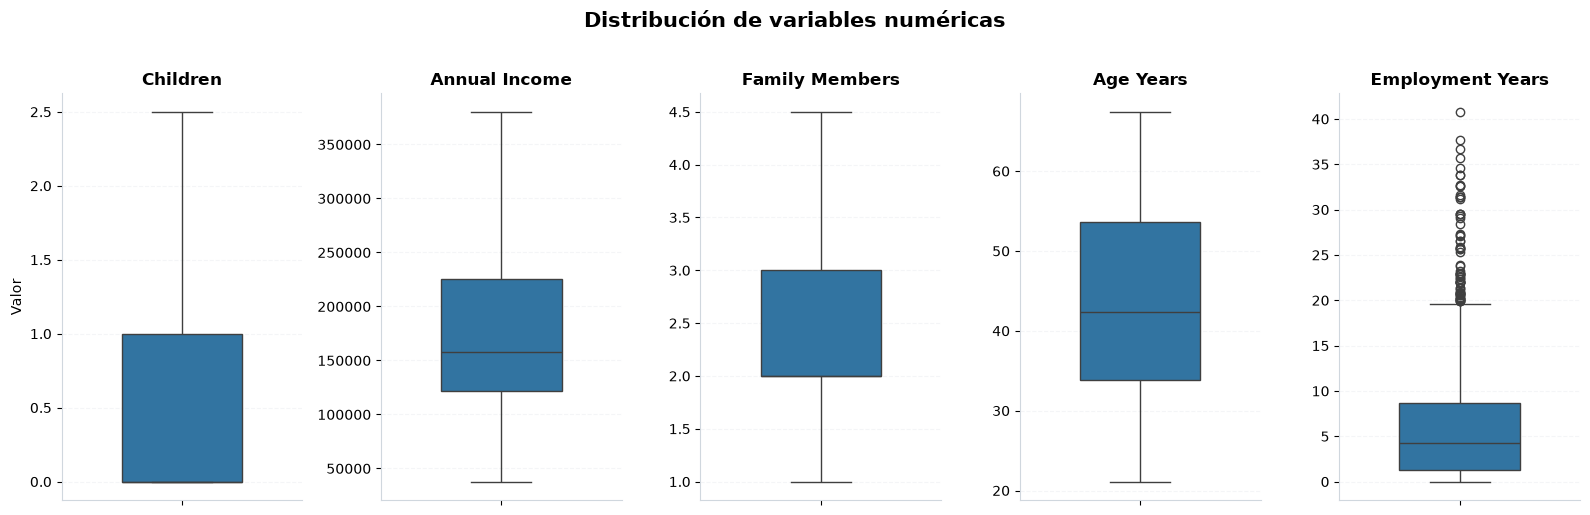

In [172]:
num_cols = ['children','annual_income','family_members','age_years','employment_years']

fig, axes = plt.subplots(
    ncols=len(num_cols),
    nrows=1,
    figsize=(16, 5)
)

for i, col in enumerate(num_cols):

    sns.boxplot(
        data=X_train,
        y=col,
        ax=axes[i],
        width=0.5
    )

    axes[i].set_title(
        col.replace('_', ' ').title(),
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor' if i == 0 else '')

    axes[i].grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle(
    'Distribución de variables numéricas',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

A continuación graficaremos nuestro mapa de calor para verificar si existe correlación entre nuestras variables numéricas.  

In [173]:
# Definimos nuestras variables por tipo

num_cols = ['annual_income', 'family_members', 'children','age_years', 'employment_years']
cat_cols = ['gender', 'type_income','education', 'marital_status', 'housing_type', 'type_occupation']
bin_cols = ['car_owner', 'propert_owner', 'work_phone', 'phone', 'email_id']

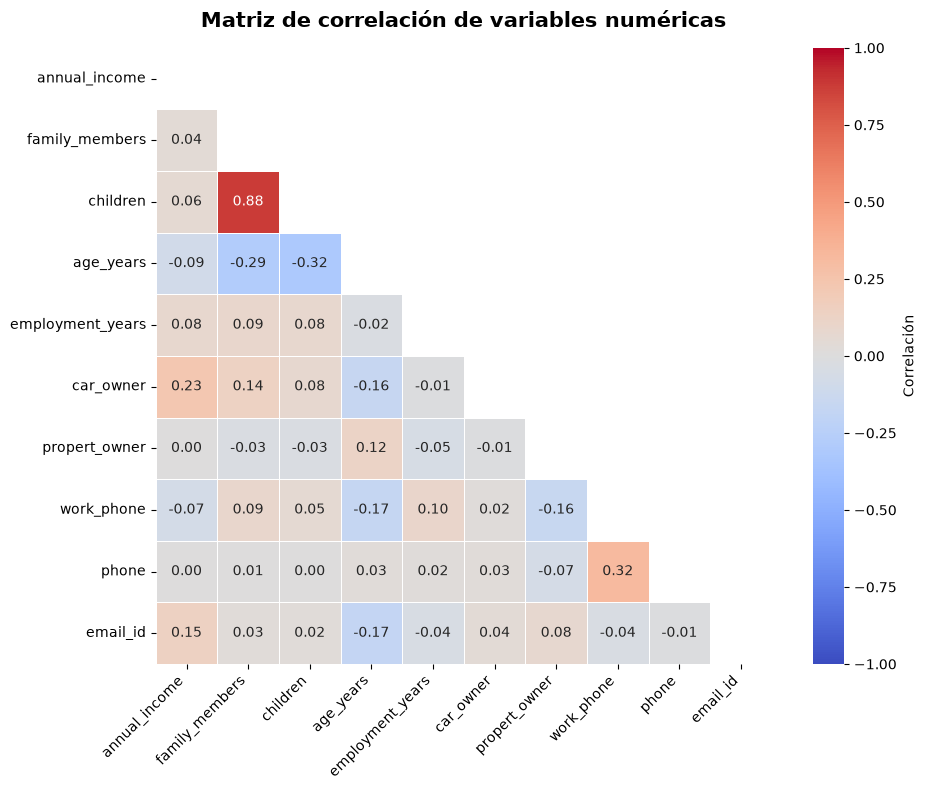

In [174]:
variables = num_cols + bin_cols

correlation_matrix = X_train[variables].corr()

# Máscara para ocultar la parte superior
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlación"}
)

plt.title(
    "Matriz de correlación de variables numéricas",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Observamos que existe una correlación postiva entre las variables `children` y `family_members`, esto ya lo habiamos visto en el EDA, ahora aplicaremos el VIF para decidir si es conveniente eliminar una de ellas o no. 

## Analisis del VIF (Variance Inflation Factor) - multicolinealidad

In [175]:
# importamos librerias
from statsmodels.stats.outliers_influence import variance_inflation_factor

variables = num_cols + bin_cols

#aplicamos solo en entrenamiento. 
num_cols_vif = [column for column in variables]
X_vif = X_train[num_cols_vif].dropna()


X_vif_const = pd.concat([pd.Series(1.0, index=X_vif.index, name='const'), X_vif], axis=1)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

vif_data = vif_data[vif_data['Variable'] != 'const']  # descartamos la fila de la constante
vif_data.sort_values('VIF', ascending=False)

,Variable,VIF
3,children,4.478952
2,family_members,4.432798
4,age_years,1.236324
8,work_phone,1.204415
9,phone,1.126947
6,car_owner,1.111120
1,annual_income,1.101797
10,email_id,1.068064
7,propert_owner,1.046325
5,employment_years,1.030961


Un VIF > 5, podria afectar a nuestro modelo. Sin embargo, observamos tanto `children` y `family_members` no superan ese umbral y continuaremos usando las variables para entrenar el modelo. 

## One-hot Encodding

A continuacion transformaremos nuestras variables categoricas a números binarios. Solo aplicaremos a train, luego ajustaremos a test con reindex para evitar categorias nuevas no vistas. 

In [176]:
# drop_first=True elimina la primera columna para evitar la trampa de multicolinealidad
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Alineamos las columnas del Train/Test
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Verificamos si tienen las mismas columnas
print("Shapes:", X_train_enc.shape, X_test_enc.shape)
print("Columnas iguales:", list(X_train_enc.columns) == list(X_test_enc.columns))

Shapes: (1238, 27) (310, 27)
Columnas iguales: True


## Escalado de variables

Usaremos `standarscaler` para ajustrar y transformar nuestras variables numéricas para que tengan una media de 0 y una std de 1. Ajustaremos solo a train, y luego transformaremos a test.

In [177]:
scaler = StandardScaler()
X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_enc[num_cols] = scaler.transform(X_test_enc[num_cols]) 

print(X_train_enc[num_cols].describe())  # media ~0, std ~1
print(X_train_enc.isna().sum().sum(), X_test_enc.isna().sum().sum())  # deben ser 0
print(list(X_train_enc.columns) == list(X_test_enc.columns))  # deben ser iguales

       annual_income  family_members      children     age_years  \
count   1.238000e+03    1.238000e+03  1.238000e+03  1.238000e+03   
mean    8.537418e-17   -1.951410e-16  5.739441e-17 -8.609161e-17   
std     1.000404e+00    1.000404e+00  1.000404e+00  1.000404e+00   
min    -1.773387e+00   -1.291557e+00 -6.002601e-01 -1.954374e+00   
25%    -7.463392e-01   -1.714537e-01 -6.002601e-01 -8.597054e-01   
50%    -3.045981e-01   -1.714537e-01 -6.002601e-01 -1.316541e-01   
75%     5.236663e-01    9.486500e-01  8.554147e-01  8.371960e-01   
max     2.428674e+00    2.628806e+00  3.038927e+00  2.028938e+00   

       employment_years  
count      1.238000e+03  
mean       1.721832e-17  
std        1.000404e+00  
min       -9.148168e-01  
25%       -7.266907e-01  
50%       -2.706894e-01  
75%        3.724155e-01  
max        5.173516e+00  
0 0
True


In [178]:
# Realizamos copia de seguridad
X_train = X_train_enc.copy()
X_test = X_test_enc.copy()

print("X_train_final:", X_train.shape, " X_test_final:", X_test.shape)
X_train.head()

X_train_final: (1238, 27)  X_test_final: (310, 27)


,car_owner,propert_owner,children,annual_income,work_phone,phone,email_id,family_members,is_retired_unemployed,age_years,...,marital_status_Married,marital_status_Separated,marital_status_Single / not married,marital_status_Widow,housing_type_Rent,housing_type_With parents,type_occupation_Hospitality_Support,type_occupation_Sales_Services,type_occupation_Unknown,type_occupation_White_Collar
310,0,0,-0.600260,-0.580686,0,0,0,-0.171454,0,0.271955,...,True,False,False,False,False,False,False,False,False,False
1484,1,1,-0.600260,-0.580686,1,0,0,-0.171454,0,-0.901174,...,True,False,False,False,False,False,False,False,False,True
1210,0,0,-0.600260,-0.856774,0,0,0,-0.171454,0,-1.332585,...,True,False,False,False,False,False,False,False,False,False
829,1,0,-0.600260,-0.028510,1,0,0,-0.171454,0,-0.451384,...,True,False,False,False,True,False,False,False,False,False
53,1,0,0.855415,-0.580686,0,0,0,0.948650,0,-1.509297,...,True,False,False,False,False,False,False,False,False,False


## Entrenamiento y Benchmark de modélos básicos.

A continuación entranaremos nuestros modelos básicos. Vamos a priorizar `Recall` porque estamos en la busqueda de morosos, ya que recall hace una muy buena pregunta: De todos los morosos reales, ¿Cuántos detectó el modelo?.

Además, teniendo en cuenta lo siguiente: 

- Falsos negativos -> El modelo dice que es un buen pagador, pero en realidad era moroso --> costo $8.000

- Falsos positivo -> El modelo dice que es moroso, pero en realidad no era buen pagador --> costo $8.000

In [179]:
from sklearn.metrics import roc_auc_score, recall_score, f1_score

# Definición de Modelos (Añadimos class_weight='balanced' por los morosos)
modelos = {
    "Logistica" : LogisticRegression(
        max_iter=1000,
        class_weight ='balanced',
        random_state = 42
        ),
    "Árbol": DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
        ),
    "Random Forest Base" : RandomForestClassifier(
         n_estimators = 100,
         class_weight = 'balanced',
         random_state = 42
    )
}

predicciones = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    proba = modelo.predict_proba(X_test)[:,1]
    pred = modelo.predict(X_test)
    predicciones[nombre] = {'modelo': modelo, 'proba':proba, 'pred':pred}
    print(f"{nombre}: entrenado.")

Logistica: entrenado.
Árbol: entrenado.
Random Forest Base: entrenado.


In [184]:
def calcular_metricas(y_true, pred, proba):
    return {
        'ROC-AUC': roc_auc_score(y_true, proba),
        'Recall': recall_score(y_true, pred),
        'F1-score': f1_score(y_true, pred),
        'Accuracy': accuracy_score(y_true, pred),
    }

resultados = []

for nombre, d in predicciones.items():
    m = calcular_metricas(y_test, d['pred'], d['proba'])
    m['Modelo'] = nombre
    resultados.append(m)

benchmark = pd.DataFrame(resultados)[['Modelo', 'ROC-AUC', 'Recall', 'F1-score', 'Accuracy']]

# Multiplicar solamente las métricas por 100
metricas = ['ROC-AUC', 'Recall', 'F1-score', 'Accuracy']
benchmark[metricas] = (benchmark[metricas] * 100).round(2)

benchmark = (
benchmark
    .sort_values('Recall', ascending=False)
    .reset_index(drop=True)
)

display(benchmark.style.background_gradient(cmap='Greens', subset=['ROC-AUC','Recall','F1-score','Accuracy']))

,Modelo,ROC-AUC,Recall,F1-score,Accuracy
0,Logistica,70.590000,62.860000,28.570000,64.520000
1,Random Forest Base,84.220000,51.430000,59.020000,91.940000
2,Árbol,64.610000,42.860000,26.790000,73.550000


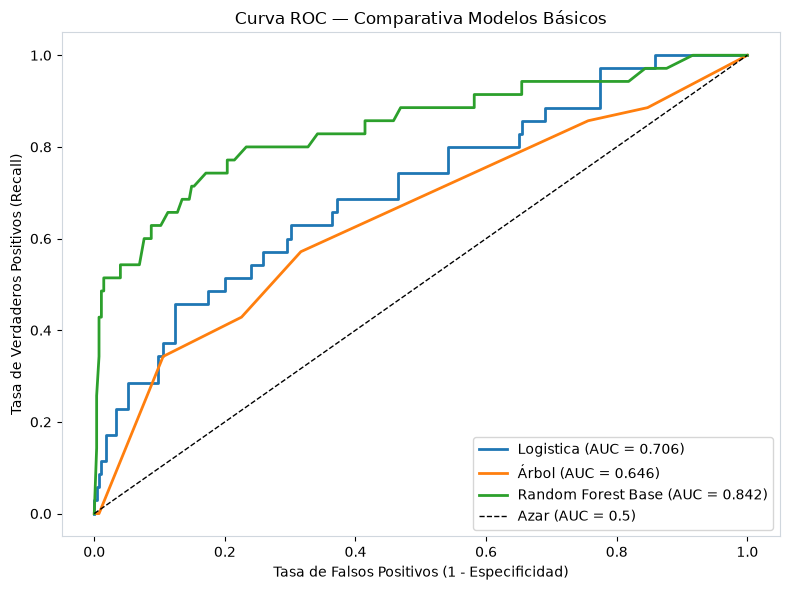

In [188]:
from sklearn.metrics import roc_curve


colors = {'Logistic Regression': '#4C72B0', 'Decision Tree': '#DD8452', 'Random Forest': '#55A868'}

plt.figure(figsize=(8, 6))

for nombre, d in predicciones.items():
    fpr, tpr, _ = roc_curve(y_test, d['proba'])
    auc = roc_auc_score(y_test, d['proba'])
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.3f})", color=colors.get(nombre), linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC — Comparativa Modelos Básicos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


[[178  97]
 [ 13  22]]
[[213  62]
 [ 20  15]]
[[267   8]
 [ 17  18]]


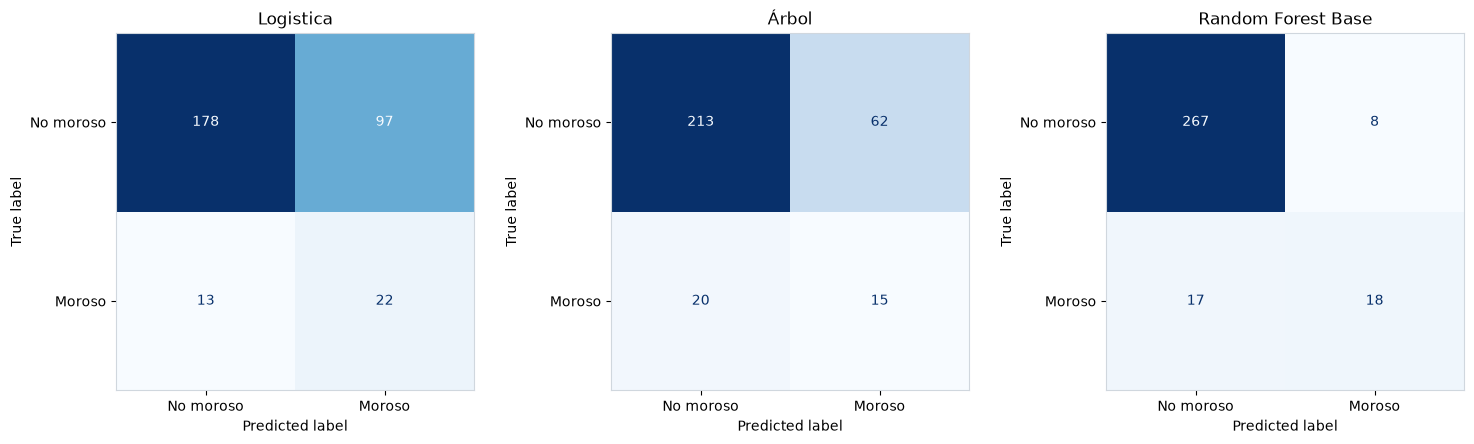

In [194]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
for ax, (nombre, d) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, d['pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No moroso','Moroso'])
    print(cm)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nombre)
plt.tight_layout(); plt.show()